# Adult Census Income: GridSearchCV и финальная модель

На этом этапе:

- загружаем выбранные модели из предыдущего этапа
- делаем небольшую гиперпараметрическую оптимизацию через **GridSearchCV**
- выбираем лучшую модель по метрике `roc_auc`
- оцениваем качество на отложенном `X_test`
- сохраняем лучшую модель и метрики в `data/`

## Импорты и настройки

In [1]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)

import joblib

import sys

sys.path.append(str(Path.cwd()))
sys.path.append(str(Path.cwd() / "src"))

from adult_income_utils import (
    RANDOM_STATE,
    add_features,
    get_feature_lists,
    load_clean_adult_data,
    make_X_y,
    make_preprocessor,
)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Подготовка данных

Используем тот же пайплайн признаков, что и в предыдущих ноутбуках

Очищенные данные -> feature engineering -> train/test split со stratify


In [2]:
df_clean = load_clean_adult_data()
df_features = add_features(df_clean)

X, y = make_X_y(df_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

numerical_features, categorical_features = get_feature_lists(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

X_train shape: (39032, 21)
X_test shape: (9758, 21)
y_train distribution:
income
0    0.760581
1    0.239419
Name: proportion, dtype: float64


## CV и метрики

Для сравнимости используем `StratifiedKFold` (5 folds) и тот же набор метрик, `refit` делаем по `roc_auc`

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics = {
    "accuracy": "accuracy",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
}

refit_metric = "roc_auc"
print(f"CV: {cv.get_n_splits()} folds, refit={refit_metric}")

CV: 5 folds, refit=roc_auc


## Загрузка топ-моделей из предыдущего этапа

Берем `best_models.json`, который сохранился после сравнения моделей

In [5]:
best_models_path = Path("..") / "data" / "best_models.json"

if best_models_path.exists():
    with open(best_models_path, "r", encoding="utf-8") as f:
        best_models_info = json.load(f)
    top_model_names = best_models_info.get("top_models", [])
else:
    best_models_info = {}
    top_model_names = []

print("best_models.json found:", best_models_path.exists())
print("Top models:", top_model_names)

if len(top_model_names) == 0:
    print("\nФайл не найден или пустой. Использую дефолтный список кандидатов.")
    top_model_names = ["LogisticRegression", "RandomForest"]

top_model_names

best_models.json found: True
Top models: ['GradientBoosting', 'LogisticRegression']


['GradientBoosting', 'LogisticRegression']

## GridSearchCV для выбранных моделей

Делаем небольшие сетки параметров, чтобы поиск занимал меньше времени

In [6]:
models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

param_grids = {
    "LogisticRegression": {
        "model__C": [0.1, 1.0, 3.0],
        "model__solver": ["lbfgs"],
    },
    "KNN": {
        "model__n_neighbors": [5, 15, 25],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "DecisionTree": {
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2, 5],
        "model__criterion": ["gini", "entropy"],
    },
    "RandomForest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 15, 30],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"],
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__subsample": [0.8, 1.0],
    },
}

gridsearch_results = {}
gridsearch_summary = []

for model_name in top_model_names:
    if model_name not in models:
        print(f"Skip {model_name}: model not found")
        continue
    if model_name not in param_grids:
        print(f"Skip {model_name}: param grid not defined")
        continue

    print("\n" + "=" * 60)
    print(f"GridSearchCV for {model_name}")
    print("=" * 60)

    preprocessor = make_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", models[model_name]),
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring=scoring_metrics,
        refit=refit_metric,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )

    grid.fit(X_train, y_train)
    gridsearch_results[model_name] = grid

    print(f"Best CV {refit_metric}: {grid.best_score_:.4f}")
    print("Best params:")
    print(grid.best_params_)

    gridsearch_summary.append({
        "Model": model_name,
        f"best_cv_{refit_metric}": grid.best_score_,
        "n_candidates": len(grid.cv_results_["params"]),
    })

gridsearch_summary_df = pd.DataFrame(gridsearch_summary)
gridsearch_summary_df = gridsearch_summary_df.sort_values(f"best_cv_{refit_metric}", ascending=False)
gridsearch_summary_df


GridSearchCV for GradientBoosting
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV roc_auc: 0.9247
Best params:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}

GridSearchCV for LogisticRegression
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV roc_auc: 0.9103
Best params:
{'model__C': 3.0, 'model__solver': 'lbfgs'}


,Model,best_cv_roc_auc,n_candidates
0,GradientBoosting,0.924692,16
1,LogisticRegression,0.910285,3


## Выбор лучшей модели и оценка на `X_test`

Берем лучшую конфигурацию по CV (`roc_auc`) и проверяем финалное качество на тестовой выборке

In [7]:
if len(gridsearch_summary_df) == 0:
    raise RuntimeError("GridSearchCV results are empty. Проверь top_model_names и param_grids.")

best_model_name = gridsearch_summary_df.iloc[0]["Model"]
best_grid = gridsearch_results[best_model_name]
best_estimator = best_grid.best_estimator_

print("Best model by CV:", best_model_name)
print("Best CV roc_auc:", round(best_grid.best_score_, 4))
print("Best params:")
print(best_grid.best_params_)

y_pred = best_estimator.predict(X_test)
if hasattr(best_estimator, "predict_proba"):
    y_score = best_estimator.predict_proba(X_test)[:, 1]
else:
    y_score = best_estimator.decision_function(X_test)

test_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_score)),
}

print("\n=== Test metrics ===")
for k, v in test_metrics.items():
    print(f"{k:18} -> {v:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred))

Best model by CV: GradientBoosting
Best CV roc_auc: 0.9247
Best params:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}

=== Test metrics ===
accuracy           -> 0.8765
f1                 -> 0.7177
balanced_accuracy  -> 0.8009
roc_auc            -> 0.9294

=== Classification report ===
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7422
           1       0.79      0.66      0.72      2336

    accuracy                           0.88      9758
   macro avg       0.84      0.80      0.82      9758
weighted avg       0.87      0.88      0.87      9758



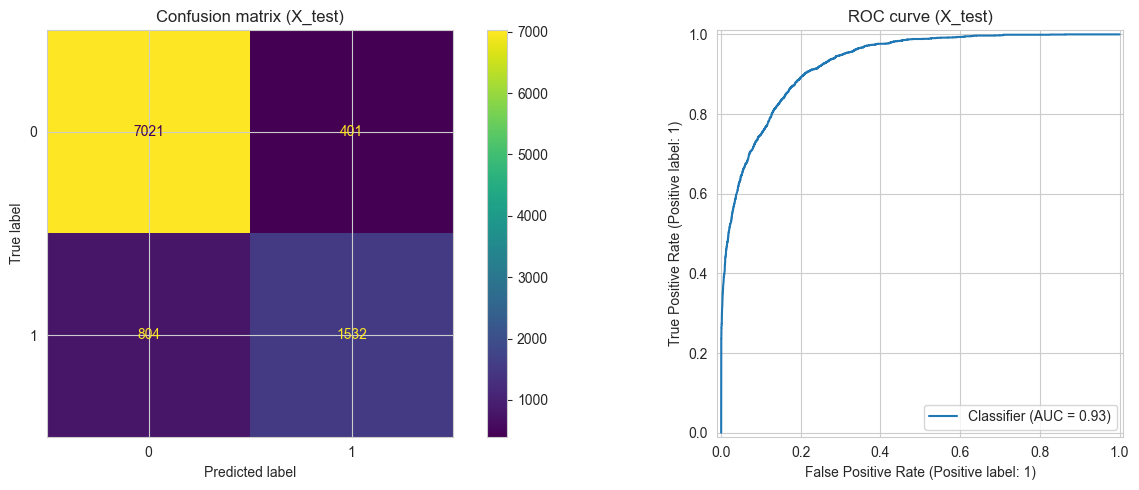

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title("Confusion matrix (X_test)")

RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].set_title("ROC curve (X_test)")

plt.tight_layout()
plt.show()

## Сохранение модели и отчета

Сохраняем лучший estimator (`joblib`) и JSON с параметрами/метриками

In [9]:
artifacts_dir = Path("..") / "data"
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / "best_model_gridsearch.joblib"
report_path = artifacts_dir / "final_model_report.json"

joblib.dump(best_estimator, model_path)

final_report = {
    "best_model": best_model_name,
    "best_params": best_grid.best_params_,
    "best_cv_metric": refit_metric,
    "best_cv_score": float(best_grid.best_score_),
    "test_metrics": test_metrics,
    "top_models_input": top_model_names,
}

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)

print("Saved artifacts:")
print(" -", model_path)
print(" -", report_path)

Saved artifacts:
 - ..\data\best_model_gridsearch.joblib
 - ..\data\final_model_report.json


## Итоги

✓ Провели GridSearchCV для топ-моделей

✓ Выбрали лучшую модель по `roc_auc`

✓ Проверили качество на `X_test`

✓ Сохранили модель и отчёт в `data/`